## Generating synthetic datasets for various genes

## Toying with synthetic data generation, copy of fig3 notebook. 

Required packages:

In [65]:
# processing
import numpy as np
import pandas as pd
from Bio import SeqIO

# custom packages
import tregs

# visualization
import matplotlib.pyplot as plt

from tregs.mpl_pboc import plotting_style

plt.rcParams.update({'font.size': 12})
plotting_style()

fdir = '../data/'

### tff-rpsB-tsf

To construct synthetic datasets, we first need to load the sequences and the energy matrices. Let us first read in the sequence of the entire *E. coli* genome.

In [66]:
_genome = []
for record in SeqIO.parse(fdir + "mg1655_genome.fasta", "fasta"):
    _genome.append(str(record.seq))
genome = _genome[0]

Next, we load the following dataframe, which contains information about the transcription start site (tss) of each gene.

In [67]:
df = pd.read_csv(fdir + 'ecoli_gene_list.csv')
df.head()
print(df[df['gene'] == 'tff'].index)
print(df.gene[3500])
print(df.promoter[3500])

Index([3500], dtype='int64')
tff
rpsBp


In this notebook, we would like to construct synthetic datasets for various genes. We start with tff. We use the function `get_regulatory_region` in the `tregs` package to access the 160 base-pair sequence around the TSS (115 base-pair upstream of the TSS and 45 base-pair downstream of the TSS).

In [68]:
tff_TSS = int(df[(df.gene == 'tff') & (df.promoter == 'rpsBp')]['tss'].iloc[0])
promoter = tregs.seq_utils.get_regulatory_region(genome, tff_TSS, reverse=True)
promoter

promoter[71:80]


'GTCGCTTCC'

We manually specify the binding site sequences. Note that these sequences all need to be contained within the promoter sequence itself.

We find the locations for start sites from the 2020eLife supplementary table. 

In [69]:
rnap_site_1 = promoter[71:81]
rnap_site_2 = promoter[97:107]
rnap_site = promoter[71:107]
rep_site = promoter[107:123]

rep_site



'GGAAGTCCGGCGCGCT'

Read in Energy Matrices from 2020 E. Life paper. Pulling for "heat" enviornment. We use the function `fix_wt` from the `tregs` package to normalize the energy matrix such that the wild type base identities correspond to a binding energy of $0\ k_BT$.

In [70]:

rnap_1_emat_raw = np.loadtxt(fdir + 'energy_matrices/tff-rpsB-tsf_heat_71_80_energymatrix.txt', dtype = str)
rnap_1_emat_raw = rnap_1_emat_raw[1:, 1:].astype(float)
rnap_1_emat = tregs.simulate.fix_wt(rnap_1_emat_raw, rnap_site_1)

rnap_2_emat_raw = np.loadtxt(fdir + 'energy_matrices/tff-rpsB-tsf_heat_97_106_energymatrix.txt', dtype = str)
rnap_2_emat_raw = rnap_2_emat_raw[1:, 1:].astype(float)
rnap_2_emat = tregs.simulate.fix_wt(rnap_2_emat_raw, rnap_site_2)

print(rnap_1_emat)
print(rnap_2_emat)

#I want a combined RNAP matrix, filling in zeros between the -35 and -10 signatures. 

rnap_emat = np.zeros((107-71, 4))

rnap_emat[:len(rnap_1_emat), :] = rnap_1_emat
rnap_emat[-len(rnap_2_emat):, :] = rnap_2_emat
print(rnap_emat)


rep_emat_raw = np.loadtxt(fdir + 'energy_matrices/tff-rpsB-tsf_heat_107_122_energymatrix.txt', dtype = str)
rep_emat_raw = rep_emat_raw[1:, 1:].astype(float)
rep_emat = tregs.simulate.fix_wt(rep_emat_raw, rep_site)

[[ 0.06512   0.013594  0.       -0.009634]
 [ 0.028963 -0.028364  0.002166  0.      ]
 [ 0.064309  0.        0.026395  0.029333]
 [ 0.053921 -0.028024  0.       -0.007985]
 [ 0.018888  0.        0.003971 -0.016787]
 [-0.048062 -0.024038 -0.000847  0.      ]
 [ 0.066616  0.005882  0.035939  0.      ]
 [-0.055849  0.       -0.018076 -0.02459 ]
 [ 0.05475   0.        0.047214  0.2016  ]
 [ 0.00066  -0.048277  0.        0.072137]]
[[ 0.003915  0.029332  0.        0.082992]
 [ 0.       -0.043055  0.068886 -0.031199]
 [ 0.       -0.017108 -0.009207  0.142835]
 [ 0.       -0.019476  0.141098  0.002134]
 [ 0.019401 -0.012201  0.043133  0.      ]
 [ 0.006921  0.017868  0.        0.17207 ]
 [ 0.211476 -0.008088  0.       -0.0003  ]
 [ 0.       -0.01173  -0.000763  0.111281]
 [ 0.174336 -0.014157  0.042529  0.      ]
 [ 0.109776  0.       -0.014041  0.009481]]
[[ 0.06512   0.013594  0.       -0.009634]
 [ 0.028963 -0.028364  0.002166  0.      ]
 [ 0.064309  0.        0.026395  0.029333]
 [ 0.0539

### 2. Simple repression with tff-rpsB-tsf

The code for generating synthetic datasets and plotting summarry statistics is very similar for the other regulatory architecture.

For a promoter with the simple repression regulatory architecture, we need the following parameters:
- the number of non-specific binding sites (`n_NS`)
- copy number of RNAP (`n_p`)
- copy number of the repressor (`n_r`)
- binding energy of the RNAP at the wild-type binding site (`ep_wt`)
- binding energy of the repressor at the wild-type binding site (`er_wt`)

Here, we use the known copy number and binding energy of the lacI repressor.

In [71]:
n_NS = len(genome)
n_p = 5000
n_r = 50
ep_wt = -5
er_wt = -15

df = tregs.simulate.sim(promoter, tregs.simulate.simrep_pbound, [rnap_site, rep_site], 
                        *[n_NS, n_p, n_r, rnap_emat, rep_emat, ep_wt, er_wt],
                        num_mutants=2*10**4)

df.to_csv('../out/tff_rpsB-tsf20k.csv')

From the synthetic dataset for the simple repression promoter, we plot the information footprint and expression shift matrix.

findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: 

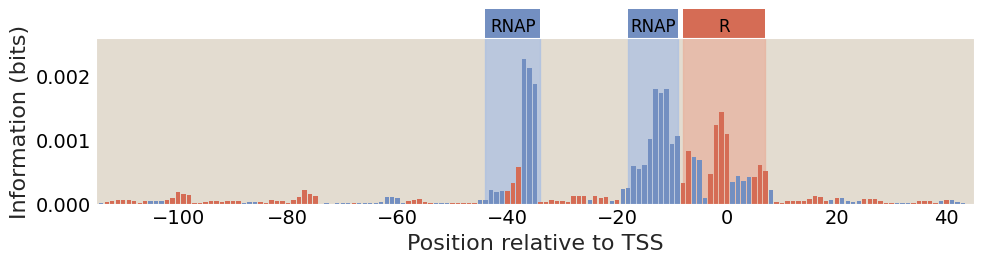

In [72]:
region_params = [(71 - 115, 81 - 115, 'P', 'RNAP'), (97-115, 106-115, 'P', 'RNAP'), (122-115, 107-115, 'R', 'R')]
tregs.footprint.plot_footprint(promoter, df, region_params)

## Repression Activation with ykgE

This doesn't seem to work. I don't know why yet. 

In [103]:
#rnap_site = promoter[60:79]#43-78
#Try reusiing the same RNAP matrix
rep_site = promoter[71:94]#71-93
act_site = promoter[13:36]#13-35

"""
rnap_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_40_79_energymatrix.txt', dtype = str)
rnap_emat_raw = rnap_emat_raw[1:, 1:].astype(float)
rnap_emat = tregs.simulate.fix_wt(rnap_emat_raw, rnap_site)

rep_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_71_93_energymatrix.txt', dtype = str)
rep_emat_raw = rep_emat_raw[1:, 1:].astype(float)
rep_emat = tregs.simulate.fix_wt(rep_emat_raw, rep_site)

act_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_13_35_energymatrix.txt', dtype = str)
act_emat_raw = act_emat_raw[1:, 1:].astype(float)
act_emat = tregs.simulate.fix_wt(act_emat_raw, act_site)

print(rnap_emat)
"""

"\nrnap_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_40_79_energymatrix.txt', dtype = str)\nrnap_emat_raw = rnap_emat_raw[1:, 1:].astype(float)\nrnap_emat = tregs.simulate.fix_wt(rnap_emat_raw, rnap_site)\n\nrep_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_71_93_energymatrix.txt', dtype = str)\nrep_emat_raw = rep_emat_raw[1:, 1:].astype(float)\nrep_emat = tregs.simulate.fix_wt(rep_emat_raw, rep_site)\n\nact_emat_raw = np.loadtxt(fdir + 'energy_matrices/ykgE_Anaero_13_35_energymatrix.txt', dtype = str)\nact_emat_raw = act_emat_raw[1:, 1:].astype(float)\nact_emat = tregs.simulate.fix_wt(act_emat_raw, act_site)\n\nprint(rnap_emat)\n"

There is a problem with the infered energy matrices. Try to use synthetic energy matrices, the comparison may still be worthwhile. 

findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: 

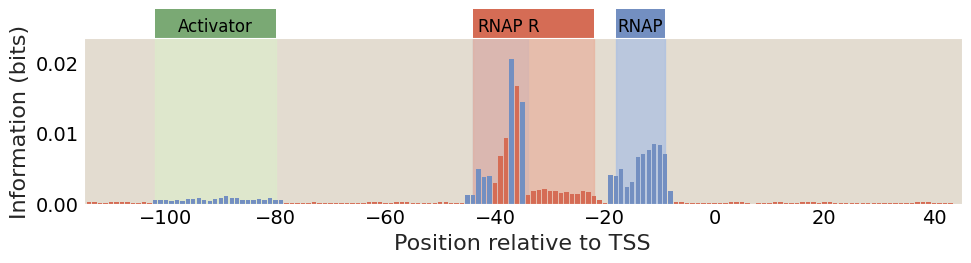

In [105]:
n_NS = len(genome)
n_p, n_r, n_a = 5000, 50, 10
ep_wt, er_wt, ea_wt = -5, -11, -5
e_int = -8

#rnap_emat = tregs.simulate.generate_emap(rnap_site, max_mut_energy=1)
act_emat = tregs.simulate.generate_emap(act_site, max_mut_energy=1)
rep_emat = tregs.simulate.generate_emap(rep_site, max_mut_energy=1)
df = tregs.simulate.sim(promoter, tregs.simulate.repact_pbound, [rnap_site, rep_site, act_site],
                        *[n_NS, n_p, n_r, n_a, rnap_emat, rep_emat, act_emat, ep_wt, er_wt, ea_wt, e_int], scaling_factor=10*6,
                        num_mutants=2*10**4)

df.to_csv('../out/ykgE20k.csv')

region_params = [(71 - 115, 81 - 115, 'P', 'RNAP'), (97-115, 106-115, 'P', 'RNAP'), (13-115, 35-115, 'A', 'Activator'), (71-115, 93-115, 'R', 'R')]
tregs.footprint.plot_footprint(promoter, df, region_params)

In [75]:
df = pd.read_csv(fdir + 'ecoli_gene_list.csv')
df.head()
print(df[df['gene'] == 'JW5041'].index)
print(df.gene[3901])
print(df.promoter[3901])

Index([], dtype='int64')
waaA
waaAp2


### 3. Simple activation with yeiQ

For a promoter with the simple activator regulatory architecture, we need the following parameters:
- the number of non-specific binding sites (`n_NS`)
- copy number of RNAP (`n_p`)
- copy number of the activator (`n_a`)
- binding energy of the RNAP at the wild-type binding site (`ep_wt`)
- binding energy of the activator at the wild-type binding site (`ea_wt`)
- interaction energy between the RNAP and the activator (`e_ap`)

Here we use CRP binding at the lacZYA promoter as a case study.

findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: 

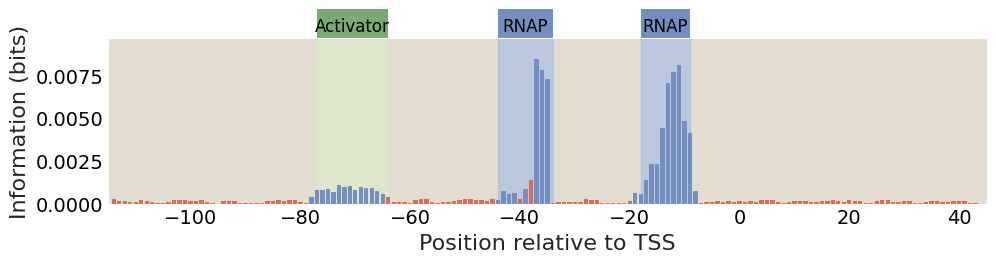

In [88]:
n_NS = len(genome)
n_p = 5000
n_a = 5
ep_wt = -10
ea_wt = -15
e_ap = -8


#promoter = 'TCCTGAACACCTTACGCCCTCAATTTTCACTCGTTGATTGATCGCCCTCACACTTCATCGCATTAACAATCCAGACCAATTTCAATTGCTGTCATATAACTTTACACTGTCGTTGTTAATTAATCGTTACTAAGACGTGACTCCTATGAATACAATCGCC'

#rnap_site = promoter[(-13+115):115]
act_site = promoter[(-77+115):(-64+115)]

#rnap_emat = tregs.simulate.generate_emap(rnap_site, max_mut_energy=1)
act_emat = tregs.simulate.generate_emap(act_site, max_mut_energy=1)


df = tregs.simulate.sim(promoter, tregs.simulate.simact_pbound, [rnap_site, act_site], 
                        *[n_NS, n_p, n_a, rnap_emat, act_emat, ep_wt, ea_wt, e_ap],
                        num_mutants=2*10**4)

df.to_csv('../out/yeiQ20k.csv')

region_params = [(71 - 115, 81 - 115, 'P', 'RNAP'), (97-115, 106-115, 'P', 'RNAP'), (-77, -64, 'A', 'Activator')]
tregs.footprint.plot_footprint(promoter, df, region_params,
                               outfile='../plots/fig3/simact.pdf')

## Double Activation with fdhE

findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: 

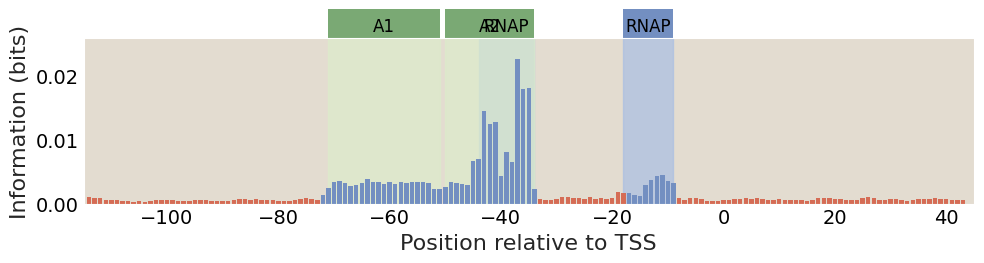

In [106]:
#promoter = 'CGTGATTATCTGGCGTCCTTATTTTGCGCCTGCTTTCTCAATCCCGGTGATCCGATTCGCGTTAATGCTGCATTCATTTGCCGCAGTGGCGTTAATTGTGGTTATCATGGTGCATATCTACGCCGCCCTTTGGGTGAAAGGCACGATTACCGCCATGGTG'
#Note: Reversed

#rnap_site = promoter[115-19:115+4]
#rnap_site = rnap_site[::-1]

act1_site = promoter[44:64]
act2_site = promoter[65:81]
#act1_site = act1_site[::-1]
#act2_site = act2_site[::-1]

#rnap_emat = tregs.simulate.generate_emap(rnap_site, fixed=True, fixed_value=1)
a1_emat = tregs.simulate.generate_emap(act1_site, fixed=True, fixed_value=0.5)
a2_emat = tregs.simulate.generate_emap(act2_site, fixed=True, fixed_value=0.5)

n_NS = len(genome)
n_p, n_a1, n_a2 = 5000, 50, 50
ep_wt, ea1_wt, ea2_wt = -2, -7, -7
e_int_pa1, e_int_pa2, e_int_a1a2 = -7, -7, -7

df = tregs.simulate.sim(promoter, tregs.simulate.doubleact_pbound, [rnap_site, act1_site, act2_site],
                        *[n_NS, n_p, n_a1, n_a2, rnap_emat, a1_emat, a2_emat, ep_wt, ea1_wt, ea2_wt, e_int_pa1, e_int_pa2, e_int_a1a2, 'OR'], scaling_factor=100,
                        num_mutants=2*10**4)

region_params = [(71 - 115, 81 - 115, 'P', 'RNAP'), (97-115, 106-115, 'P', 'RNAP'), (44-115, 64-115, 'A', 'A1'), (65-115, 81-115, 'A', 'A2')]
tregs.footprint.plot_footprint(promoter, df, region_params)

df.to_csv('../out/fdhE20k.csv')

## Double Repression with yjjJ

findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: Font family 'Lucida Sans Unicode' not found.
findfont: 

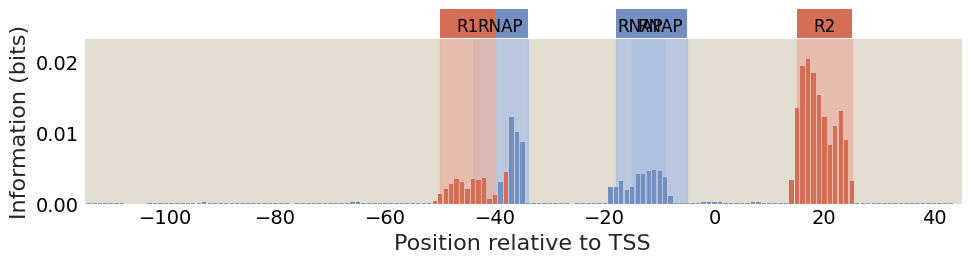

In [107]:
#rnap_site = promoter[115-19:115+4]
#rnap_emat = tregs.simulate.generate_emap(rnap_site, fixed=True, fixed_value=1)


rep1_site = promoter[(115-50):(115-40)]
rep2_site = promoter[(115+15):(115+25)]
r1_emat = tregs.simulate.generate_emap(rep1_site, max_mut_energy=0.5)
r2_emat = tregs.simulate.generate_emap(rep2_site, max_mut_energy=1)

n_NS = len(genome)
n_p, n_r1, n_r2 = 4600, 15, 15
ep_wt, er1_wt, er2_wt = -5, -12, -12
e_int = -5

df = tregs.simulate.sim(promoter, tregs.simulate.doublerep_pbound, [rnap_site, rep1_site, rep2_site],
                        *[n_NS, n_p, n_r1, n_r2, rnap_emat, r1_emat, r2_emat, ep_wt, er1_wt, er2_wt, e_int, 'OR'],
                        scaling_factor=10**6, num_mutants=2*10**4)


region_params = [(71 - 115, 81 - 115, 'P', 'RNAP'), (97-115, 106-115, 'P', 'RNAP'), (-15, -5, 'P', 'RNAP'), (-50, -40, 'R', 'R1'), (15, 25, 'R', 'R2')]
tregs.footprint.plot_footprint(promoter, df, region_params)

df.to_csv('../out/yjjJ20k.csv')
